In [1]:
import pandas as pd

RAW = "../data/raw"

In [2]:
def water_year(date):
    return date.year if date.month < 10 else date.year + 1

WY_START, WY_END = 1981, 2019

In [3]:
p = pd.read_csv(f"{RAW}/ncei_precip_monthly_v_2.csv", parse_dates=["Date"])
t = pd.read_csv(f"{RAW}/ncei_temp_monthly_v_2.csv", parse_dates=["Date"])
sm = pd.read_csv(f"{RAW}/ucrb_baseline_storage_v_2.csv", index_col=0, parse_dates=True)
flow = pd.read_csv(f"{RAW}/naturalized_flow_leesferry_monthly_v_2.csv", parse_dates=["date"])

p["ym"] = p["Date"].dt.to_period("M")
t["ym"] = t["Date"].dt.to_period("M")
sm["ym"] = sm.index.to_period("M")
flow["ym"] = flow["date"].dt.to_period("M")

ucrb = (
    p[["ym", "precip_cm"]]
    .merge(t[["ym", "temp_degC"]], on="ym")
    .merge(sm[["ym", "SM_storage[cm]"]], on="ym")
    .merge(flow[["ym", "acre_feet"]], on="ym")
)
ucrb["date"] = ucrb["ym"].dt.to_timestamp()
ucrb["wy"] = ucrb["date"].apply(water_year)
ucrb = ucrb[(ucrb["wy"] >= WY_START) & (ucrb["wy"] <= WY_END)]

ucrb["precip_in"] = ucrb["precip_cm"] / 2.54
ucrb["temp_F"] = ucrb["temp_degC"] * 9 / 5 + 32
ucrb["sm_anom_cm"] = ucrb["SM_storage[cm]"] - ucrb["SM_storage[cm]"].mean()
ucrb["flow_af"] = ucrb["acre_feet"]

ucrb_df = ucrb.set_index("date")[["precip_in", "temp_F", "sm_anom_cm", "flow_af"]]
ucrb_df.head()

,precip_in,temp_F,sm_anom_cm,flow_af
date,,,,
1980-10-01,1.401575,45.266,-0.398637,353235.0
1980-11-01,0.674409,34.538,0.246759,414120.0
1980-12-01,0.522835,33.332,0.576002,414830.0
1981-01-01,0.435039,30.596,0.390929,331854.0
1981-02-01,0.562992,30.722,0.391620,320685.0


In [6]:
sb_pt = pd.read_csv(f"{RAW}/stonybrook_precip_temp_monthly_v_2.csv")
sb_sm = pd.read_csv(f"{RAW}/stonybrook_soilmoisture_monthly_v_2.csv")
sb_flow = pd.read_csv(f"{RAW}/stonybrook_streamflow_monthly_v_2.csv", parse_dates=["date"])

sb = sb_pt.merge(sb_sm[["year", "month", "soilm_basin_avg"]], on=["year", "month"])
sb["date"] = pd.to_datetime(sb[["year", "month"]].assign(day=1))
sb = sb.merge(sb_flow, on="date")

sb["wy"] = sb["date"].apply(water_year)
sb = sb[(sb["wy"] >= WY_START) & (sb["wy"] <= WY_END)]

sb["precip_in"] = sb["precip_basin_avg_mm"] / 25.4
sb["temp_F"] = sb["temp_basin_avg_C"] * 9 / 5 + 32
sb["sm_cm"] = sb["soilm_basin_avg"] / 10
sb["sm_anom_cm"] = sb["sm_cm"] - sb["sm_cm"].mean()

stonybrook_df = sb.set_index("date")[["precip_in", "temp_F", "sm_anom_cm", "flow_af"]]
stonybrook_df.head()

,precip_in,temp_F,sm_anom_cm,flow_af
date,,,,
1980-10-01,4.001671,52.238794,-14.365595,703.735511
1980-11-01,3.060288,40.847070,-9.094593,1097.652851
1980-12-01,0.591536,29.660132,-4.972260,426.842959
1981-01-01,0.500541,22.905518,-4.693354,197.752059
1981-02-01,4.188929,36.284009,-0.267951,5640.396483


In [7]:
print(ucrb_df.shape, stonybrook_df.shape)
ucrb_df.describe()

(468, 4) (468, 4)


,precip_in,temp_F,sm_anom_cm,flow_af
count,468.000000,468.000000,4.680000e+02,4.680000e+02
mean,1.286660,45.509154,-6.073015e-15,1.192654e+06
std,0.602733,15.697395,3.273392e+00,1.269582e+06
min,0.056693,17.492000,-8.483872e+00,2.143340e+05
25%,0.868898,31.185500,-2.518594e+00,4.204555e+05
50%,1.205118,45.158000,-4.240001e-02,6.488655e+05
75%,1.660236,59.972000,2.407311e+00,1.314546e+06
max,3.294882,73.112000,7.279252e+00,7.586684e+06


In [18]:
stonybrook_df_monthly = stonybrook_df.groupby(stonybrook_df.index.month).mean()
ucrb_df_monthly = ucrb_df.groupby(ucrb_df.index.month).mean()

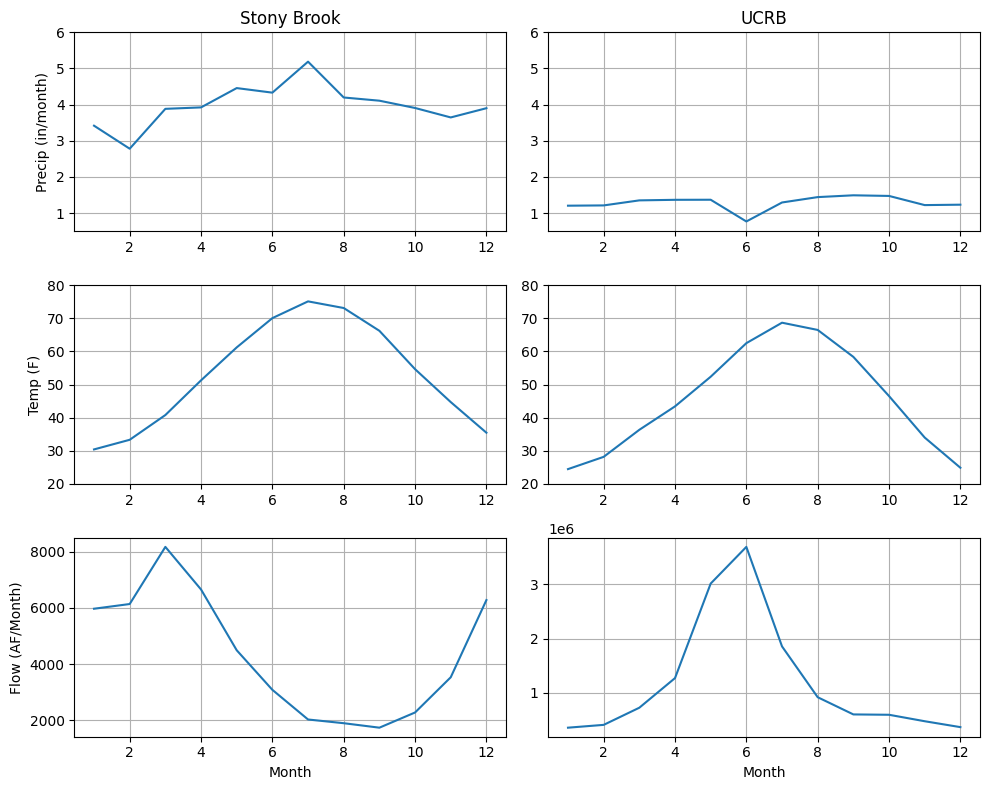

In [40]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))


###########
ax_sb_p = plt.subplot(3, 2, 1)
ax_sb_p.plot(stonybrook_df_monthly.index, stonybrook_df_monthly["precip_in"])
ax_sb_p.set_title("Stony Brook")
ax_sb_p.set_ylabel("Precip (in/month)")
ax_sb_p.set_ylim(0.5, 6)
ax_sb_p.grid()

ax_ucrb_p = plt.subplot(3, 2, 2)
ax_ucrb_p.plot(ucrb_df_monthly.index, ucrb_df_monthly["precip_in"])
ax_ucrb_p.set_title("UCRB")
ax_ucrb_p.set_ylim(0.5, 6)
ax_ucrb_p.grid()
############


############
ax_sb_t = plt.subplot(3, 2, 3)
ax_sb_t.plot(stonybrook_df_monthly.index, stonybrook_df_monthly["temp_F"])
ax_sb_t.set_ylabel("Temp (F)")
ax_sb_t.set_ylim(20,80)
ax_sb_t.grid()

ax_ucrb_t = plt.subplot(3, 2, 4)
ax_ucrb_t.plot(ucrb_df_monthly.index, ucrb_df_monthly["temp_F"])
ax_ucrb_t.set_ylim(20,80)
ax_ucrb_t.grid()
############


############
ax_sb_q = plt.subplot(3, 2, 5)
ax_sb_q.plot(stonybrook_df_monthly.index, stonybrook_df_monthly["flow_af"])
ax_sb_q.set_ylabel("Flow (AF/Month)")
ax_sb_q.set_xlabel("Month")
ax_sb_q.grid()
    
ax_ucrb_q = plt.subplot(3, 2, 6)
ax_ucrb_q.plot(ucrb_df_monthly.index, ucrb_df_monthly["flow_af"])
ax_ucrb_q.set_xlabel("Month")

ax_ucrb_q.grid()
############

plt.tight_layout()
plt.show()

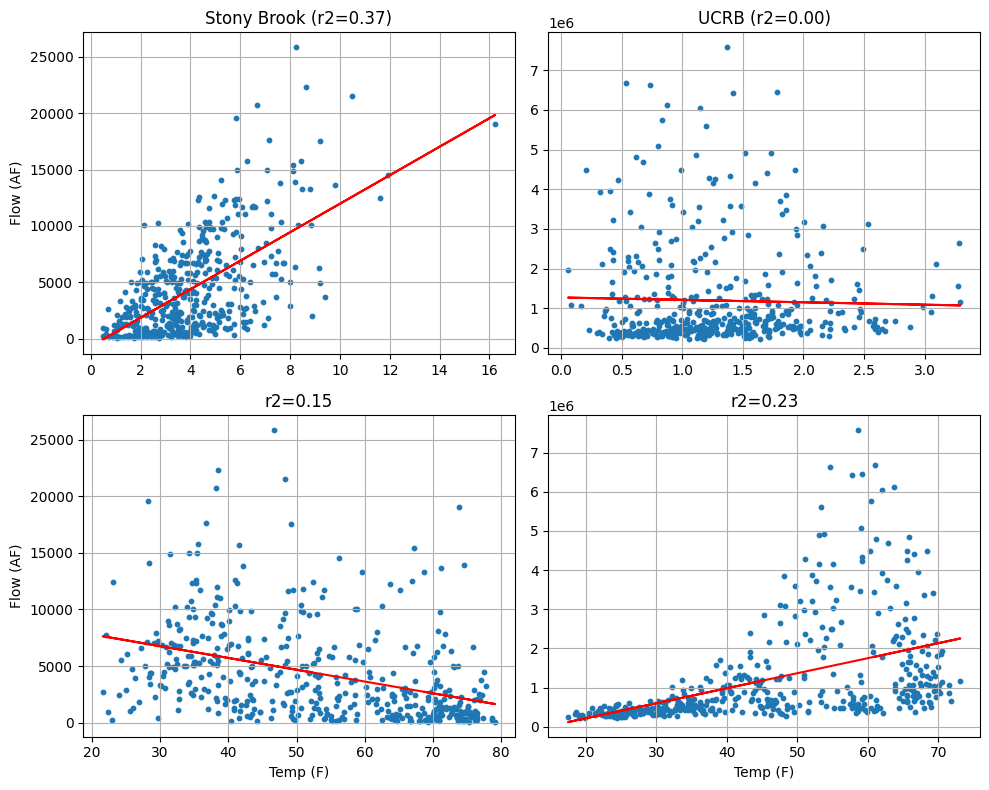

In [41]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax_sb_p.set_title("Stony Brook")
ax_ucrb_p.set_title("UCRB")

############
x = stonybrook_df["precip_in"]
y = stonybrook_df["flow_af"]
slope_sb_p, intercept_sb_p = np.polyfit(x, y, 1)
r2_sb_p = np.corrcoef(x, y)[0, 1] ** 2

ax_sb_p = plt.subplot(2, 2, 1)
ax_sb_p.scatter(x, y, s=10)
ax_sb_p.plot(x, slope_sb_p * x + intercept_sb_p, color="red")
ax_sb_p.set_title(f"Stony Brook (r2={r2_sb_p:.2f})")
ax_sb_p.set_ylabel("Flow (AF)")
ax_sb_p.grid()
############

############
x = ucrb_df["precip_in"]
y = ucrb_df["flow_af"]
slope_ucrb_p, intercept_ucrb_p = np.polyfit(x, y, 1)
r2_ucrb_p = np.corrcoef(x, y)[0, 1] ** 2

ax_ucrb_p = plt.subplot(2, 2, 2)
ax_ucrb_p.scatter(x, y, s=10)
ax_ucrb_p.plot(x, slope_ucrb_p * x + intercept_ucrb_p, color="red")
ax_ucrb_p.set_title(f"UCRB (r2={r2_ucrb_p:.2f})")
ax_ucrb_p.grid()
############

############
x = stonybrook_df["temp_F"]
y = stonybrook_df["flow_af"]
slope_sb_t, intercept_sb_t = np.polyfit(x, y, 1)
r2_sb_t = np.corrcoef(x, y)[0, 1] ** 2

ax_sb_t = plt.subplot(2, 2, 3)
ax_sb_t.scatter(x, y, s=10)
ax_sb_t.plot(x, slope_sb_t * x + intercept_sb_t, color="red")
ax_sb_t.set_title(f"r2={r2_sb_t:.2f}")
ax_sb_t.set_xlabel("Temp (F)")
ax_sb_t.set_ylabel("Flow (AF)")
ax_sb_t.grid()
############

############
x = ucrb_df["temp_F"]
y = ucrb_df["flow_af"]
slope_ucrb_t, intercept_ucrb_t = np.polyfit(x, y, 1)
r2_ucrb_t = np.corrcoef(x, y)[0, 1] ** 2

ax_ucrb_t = plt.subplot(2, 2, 4)
ax_ucrb_t.scatter(x, y, s=10)
ax_ucrb_t.plot(x, slope_ucrb_t * x + intercept_ucrb_t, color="red")
ax_ucrb_t.set_title(f"r2={r2_ucrb_t:.2f}")
ax_ucrb_t.set_xlabel("Temp (F)")
ax_ucrb_t.grid()
############

plt.tight_layout()
plt.show()